# Complement · Transformació de dades amb pandas

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/Pr%C3%A0cticaBasedeDades.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Transformar dades de format ample a llarg amb una correspondència explícita entre any i categoria.

**Abans de començar:** llistes, bucles i estadística descriptiva  
**Temps orientatiu:** 2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració de PràcticaBasedeDades.ipynb. El CSV original de l'Agència Tributària no era al repositori.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Si una taula té més files després de transformar-la, hem creat més observacions originals?

**Al final ho has de poder explicar:** Seguir cada valor des de la taula original fins al format llarg conservant persona, any, categoria i unitats.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Quines dades utilitzem?
**Aquest quadern treballa per defecte amb dades sintètiques de demostració.**
No són dades fiscals reals i no permeten conclusions sobre salaris ni impostos.
L'arxiu original `data2.csv` no està disponible al repositori i no es pressuposa
l'accés a cap Drive personal. Si disposes del CSV, pots carregar-lo a la cel·la indicada.

Reproduïm l'esquema de les columnes: ID, anys per a Salary, anys amb sufix .1 per a tax,
i anys amb sufix .2 per a employees. Les magnituds simulades no tenen unitats econòmiques assignades.


In [2]:
import pandas as pd
from pathlib import Path

def dades_demostracio(files=400, anys=range(2001, 2023), llavor=2026):
    if files < 1: raise ValueError("Cal almenys una fila.")
    rng = np.random.default_rng(llavor)
    dades = {"ID": np.arange(1, files+1)}
    for sufix, escala in (("", 10000), (".1", 2000), (".2", 500)):
        for any_ in anys:
            dades[f"{any_}{sufix}"] = rng.integers(1, escala, size=files)
    return pd.DataFrame(dades)

# Opcional: puja el CSV a Colab/Jupyter i escriu-ne la ruta. None usa dades sintètiques.
ruta_csv = None  # Exemple: "data2.csv"
if ruta_csv is None:
    dades_amples = dades_demostracio()
    origen_dades = "DADES SINTÈTIQUES DE DEMOSTRACIÓ"
else:
    dades_amples = pd.read_csv(Path(ruta_csv), dtype=str)
    origen_dades = f"Fitxer proporcionat: {Path(ruta_csv).name}"
print(origen_dades)
display(dades_amples.head())
print("Dimensions:", dades_amples.shape)


DADES SINTÈTIQUES DE DEMOSTRACIÓ


,ID,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013.2,2014.2,2015.2,2016.2,2017.2,2018.2,2019.2,2020.2,2021.2,2022.2
0,1,8518,8482,8827,7888,2084,5073,9412,9452,3753,...,234,482,25,374,354,168,131,156,454,74
1,2,1790,7744,2180,5316,7764,8035,4190,6721,7812,...,110,151,225,38,387,214,451,73,293,264
2,3,265,7224,6378,1684,889,2509,2973,2372,1802,...,292,93,137,95,102,74,421,5,253,420
3,4,6399,6521,2540,7572,6952,965,4600,8254,982,...,316,45,290,166,471,310,362,81,139,432
4,5,3655,225,5571,5154,4675,6790,6246,6322,4065,...,374,482,146,330,13,222,384,378,362,87


Dimensions: (400, 67)


## 2. Append, extend i aplanament
`append` afegeix un únic element, que pot ser una llista; `extend` afegeix
cadascun dels elements d'una seqüència. Prediu les longituds abans d'executar.


In [3]:
a, b = [], []
a.append([1, 2, 3])
b.extend([1, 2, 3])
print("append:", a, "longitud:", len(a))
print("extend:", b, "longitud:", len(b))
matriu = np.array([[1, 2, 3], [4, 5, 6]])
print("Ordre de files:", matriu.flatten("C"))
print("Ordre de columnes:", matriu.flatten("F"))


append: [[1, 2, 3]] longitud: 1
extend: [1, 2, 3] longitud: 3
Ordre de files: [1 2 3 4 5 6]
Ordre de columnes: [1 4 2 5 3 6]


## 3. Transformar sense confiar en la posició de les columnes
La nova taula tindrà les columnes `rank`, `value`, `year`, `category`.
Extraurem l'any i la categoria dels noms de les columnes. Així no depenem
de tenir exactament 400 files, 22 anys o un ordre determinat.

L'opció `comes_milers=True` només és adequada si el fitxer usa comes com a
separador de milers, com en els exemples guardats al quadern original.
No l'activis si les comes representen decimals.


In [4]:
import re

def format_llarg(ample, comes_milers=False):
    if "ID" not in ample.columns or ample["ID"].isna().any() or ample["ID"].duplicated().any():
        raise ValueError("Cal una columna ID sense valors absents ni repetits.")
    if ample.empty: raise ValueError("La taula és buida.")
    categories = {None: "Salary", "1": "tax", "2": "employees"}
    blocs, ignorades = [], []
    for columna in ample.columns:
        if columna == "ID": continue
        patro = re.fullmatch(r"(\d{4})(?:\.(\d+))?", str(columna))
        if patro is None or patro.group(2) not in categories:
            ignorades.append(str(columna)); continue
        serie = ample[columna]
        if comes_milers:
            serie = serie.astype(str).str.replace(",", "", regex=False)
        valors = pd.to_numeric(serie, errors="raise")
        if not np.isfinite(valors.to_numpy(dtype=float)).all():
            raise ValueError(f"Hi ha valors absents o no finits a {columna}.")
        blocs.append(pd.DataFrame({"rank": ample["ID"].to_numpy(), "value": valors.to_numpy(),
                                    "year": int(patro.group(1)), "category": categories[patro.group(2)]}))
    if not blocs: raise ValueError("No s'han trobat columnes d'any i categoria reconegudes.")
    llarg = pd.concat(blocs, ignore_index=True)
    if llarg.duplicated(["rank", "year", "category"]).any():
        raise ValueError("Hi ha registres repetits per identificador, any i categoria.")
    return llarg, ignorades

dades_llargues, ignorades = format_llarg(dades_amples, comes_milers=ruta_csv is not None)
print(origen_dades)
print("Columnes no utilitzades:", ignorades)
print("Dimensions del format llarg:", dades_llargues.shape)
display(dades_llargues.head())


DADES SINTÈTIQUES DE DEMOSTRACIÓ
Columnes no utilitzades: []
Dimensions del format llarg: (26400, 4)


,rank,value,year,category
0,1,8518,2001,Salary
1,2,1790,2001,Salary
2,3,265,2001,Salary
3,4,6399,2001,Salary
4,5,3655,2001,Salary


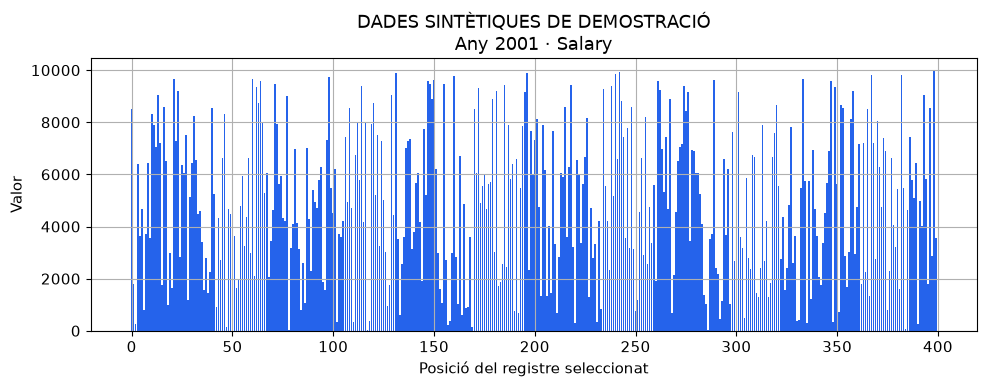

Registres seleccionats: 400


interactive(children=(Dropdown(description='any_', options=(2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 20…

In [5]:
def grafic_dades(any_=2001, categoria="Salary"):
    seleccio = dades_llargues[(dades_llargues["year"] == any_) & (dades_llargues["category"] == categoria)]
    fig, ax = plt.subplots()
    ax.bar(np.arange(len(seleccio)), seleccio["value"], color="#2563eb")
    ax.set(xlabel="Posició del registre seleccionat", ylabel="Valor",
           title=f"{origen_dades}\nAny {any_} · {categoria}")
    plt.tight_layout(); plt.show()
    print("Registres seleccionats:", len(seleccio))
panell = explora(grafic_dades, any_=sorted(dades_llargues["year"].unique().tolist()),
                 categoria=sorted(dades_llargues["category"].unique().tolist()))


## Laboratori animat · observa, atura i explica


### Segueix una dada: no perdis qui, quan i què

Abans de treballar amb milers de registres, fem-ho amb **3 identificadors i 2 anys**.
Les dades són sintètiques. Les columnes 2025 i 2026 contenen imports salarials en euros;
2025.2 i 2026.2 contenen nombre de treballadors. És el mateix conveni de noms del codi anterior.

Una cel·la com «ID 2, columna 2026, valor 24» es transforma en una fila amb
`rank=2`, `year=2026`, `category=Salary`, `value=24`. El nom de la columna aporta
l'any i la categoria; el valor numèric tot sol no conté aquesta informació.

**Prediu.** Tres identificadors × dos anys × dues categories: quantes files tindrem?
**Pausa.** Localitza la cel·la taronja a la taula ampla i reconstrueix els quatre camps
de la fila taronja del format llarg. Les altres files encara no visitades apareixen buides.
No hem creat persones noves: hem canviat la manera de representar-ne les variables.


In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [7]:
titol_laboratori = "Una cel·la es converteix en una fila amb significat"
mini_ample = pd.DataFrame({"ID": [1, 2, 3], "2025": [18, 22, 20], "2026": [20, 24, 21],
                           "2025.2": [2, 3, 4], "2026.2": [3, 4, 4]})
mini_llarg, _ = format_llarg(mini_ample)
fotogrames_laboratori = list(range(len(mini_llarg)))

def origen_registre(pas):
    fila = mini_llarg.iloc[pas]
    columna = str(int(fila["year"])) + (".2" if fila["category"] == "employees" else "")
    posicio = int(np.flatnonzero(mini_ample["ID"].to_numpy() == fila["rank"])[0])
    return posicio, columna, fila

def dibuixa_laboratori(pas, axes):
    ax, bx = axes
    posicio, columna, fila = origen_registre(pas)
    for axis in axes:
        axis.axis("off")
    ta = ax.table(cellText=mini_ample.values, colLabels=mini_ample.columns,
                  cellLoc="center", loc="center")
    ta.auto_set_font_size(False)
    ta.set_fontsize(10)
    ta.scale(1, 2)
    ta[(posicio+1, mini_ample.columns.get_loc(columna))].set_facecolor("#fed7aa")
    ta[(posicio+1, 0)].set_facecolor("#dbeafe")
    camps = ["rank", "year", "category", "value"]
    files = [[str(mini_llarg.iloc[k][c]) for c in camps] if k <= pas else ["", "", "", ""]
             for k in range(len(mini_llarg))]
    tb = bx.table(cellText=files, colLabels=["ID", "Any", "Categoria", "Valor"],
                  cellLoc="center", loc="center", colWidths=[.14, .18, .43, .2])
    tb.auto_set_font_size(False)
    tb.set_fontsize(9)
    tb.scale(1, 1.35)
    for j in range(4):
        tb[(pas+1, j)].set_facecolor("#fed7aa")
    unitat = "euros" if fila["category"] == "Salary" else "treballadors"
    ax.set_title(f"Format ample: 3 files\nID {fila['rank']}, columna {columna}: {fila['value']} {unitat}")
    bx.set_title(f"Format llarg: {pas+1} de 12 files\nConservem ID, any, categoria i valor")


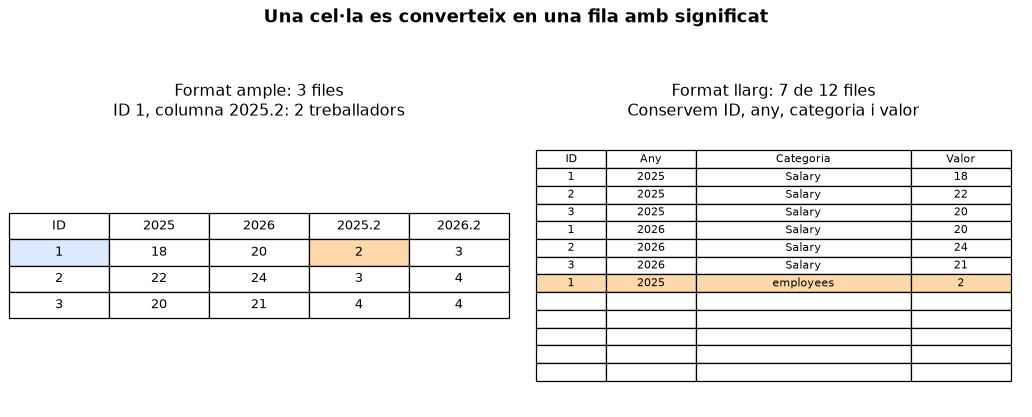

In [8]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [9]:
display(anima_laboratori())


### Compara abans de concloure

Compara el tercer i el dotzè registre transformat. Localitza l'ID, l'any i la categoria d'una fila i reconstrueix-ne la cel·la d'origen. Explica per què més files no significa més identificadors.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [10]:
parella_comparacio = (2, 11)
etiquetes_comparacio = [f"{k+1} registres visitats" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Amb 3 ID, 2 anys i 2 categories completes, quantes files hi ha en format llarg?', 'opcions': ['12', '7', '3'], 'correcta': 0, 'retorn': ["Correcte: 3×2×2=12 combinacions d'ID, any i categoria.", 'Cal multiplicar les combinacions, no sumar les dimensions.', 'Hi ha tres identificadors, però cada un apareix en quatre registres.']}, {'enunciat': 'La taula ampla i la llarga tenen un nombre diferent de files. Això significa que...', 'opcions': ['Hem creat persones noves', 'Hem canviat la representació de la mateixa informació', 'Hem perdut necessàriament dades'], 'correcta': 1, 'retorn': ["Cada fila llarga és una combinació d'ID, any i categoria, no una persona nova.", 'Correcte: cal comprovar la correspondència de cada cel·la i els seus identificadors.', 'El canvi de dimensions no implica pèrdua: cal comprovar les correspondències.']}, {'enunciat': 'Podem calcular una única mitjana barrejant Salary i employees?', 'opcions': ['Sí, perquè tots són nombres', 'Sí, si són del mateix any', 'No: barregem euros i nombre de treballadors'], 'correcta': 2, 'retorn': ['Els nombres representen magnituds diferents: la unitat també importa.', 'Compartir any no fa compatibles les unitats.', "Correcte: filtrem la categoria abans d'interpretar un resum numèric."]}]


In [11]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


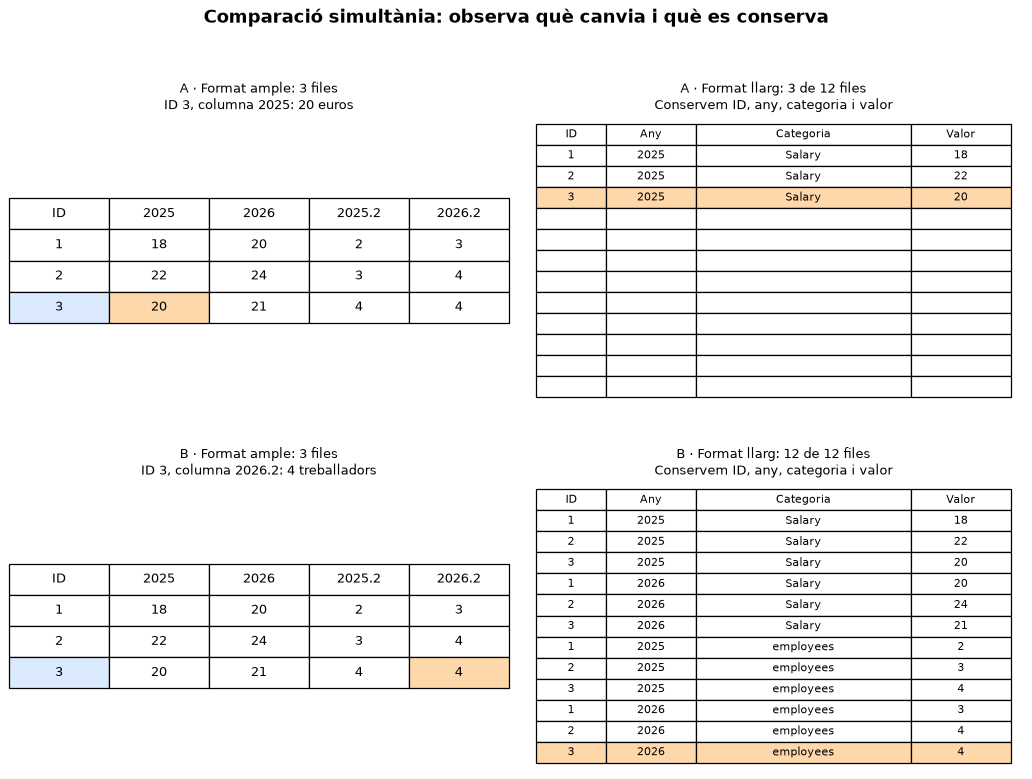

interactive(children=(Dropdown(description='Estat A:', index=2, options=(('1 registres visitats', 0), ('2 regi…

In [12]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Escull una sola categoria i compara 2025 amb 2026 per a cadascun dels tres identificadors. Abans de calcular mitjanes, indica la unitat de la variable. Prova després l'altra categoria.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


year,2025,2026
rank,,
1,18,20
2,22,24
3,20,21


Variació 2026−2025 per ID:


rank
1    2
2    2
3    1
dtype: int64

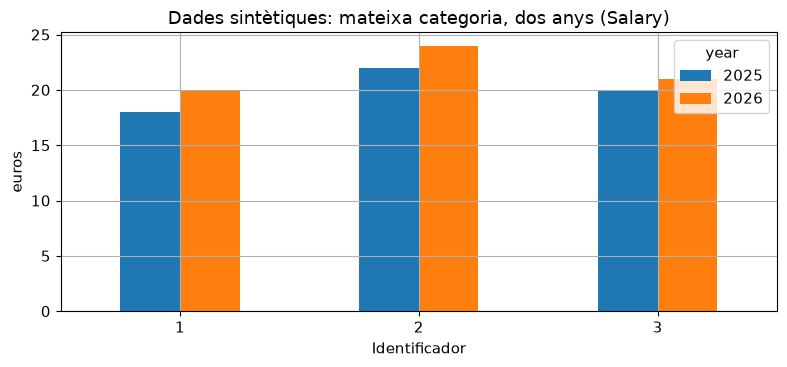

In [13]:
categoria_taller = "Salary"  # Prova també "employees".
unitats_taller = {"Salary": "euros", "employees": "treballadors"}
if categoria_taller not in unitats_taller:
    raise ValueError("Tria Salary o employees.")
seleccio_taller = mini_llarg[mini_llarg["category"] == categoria_taller]
comparacio_anys = seleccio_taller.pivot(index="rank", columns="year", values="value")
display(comparacio_anys)
print("Variació 2026−2025 per ID:")
display(comparacio_anys[2026]-comparacio_anys[2025])
ax = comparacio_anys.plot.bar(figsize=(8, 3.8), rot=0)
ax.set(xlabel="Identificador", ylabel=unitats_taller[categoria_taller],
       title=f"Dades sintètiques: mateixa categoria, dos anys ({categoria_taller})")
plt.tight_layout(); plt.show()


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Amb 3 ID, 2 anys i 2 categories completes, quantes files hi ha en format llarg?**

- A. 12
- B. 7
- C. 3

**2. La taula ampla i la llarga tenen un nombre diferent de files. Això significa que...**

- A. Hem creat persones noves
- B. Hem canviat la representació de la mateixa informació
- C. Hem perdut necessàriament dades

**3. Podem calcular una única mitjana barrejant Salary i employees?**

- A. Sí, perquè tots són nombres
- B. Sí, si són del mateix any
- C. No: barregem euros i nombre de treballadors

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [14]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Filtra només la categoria Salary de 2026 i calcula la mitjana. Quina unitat té?
2. Per què no hem de calcular una única mitjana barrejant Salary i employees?
3. Reordena les columnes de `mini_ample` i torna a aplicar `format_llarg`.
   Comprova el mateix contingut ordenant per ID, any i categoria, sense exigir el mateix ordre de files.
4. Si hi hagués 5 identificadors, 4 anys i 3 categories completes, quantes files tindria el format llarg?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [15]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

Per a Salary de 2026: (20+24+21)/3=65/3≈21,67 euros.
Barrejar euros i nombre de treballadors produeix un resum sense unitat interpretable.
La transformació ha de conservar el significat encara que canviï l'ordre de columnes;
amb 5 identificadors, 4 anys i 3 categories hi hauria 60 files.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 4. Exportació opcional
La cel·la següent no escriu cap fitxer fins que la descomentis. L'índex tècnic
del DataFrame no és una variable de les dades i no s'ha d'afegir al CSV.


In [16]:
# dades_llargues.to_csv("dades_format_llarg.csv", index=False)


## Activitats
1. Justifica el nombre de registres: 400·22·3=26400 a l'exemple per defecte.
2. Genera 10 files i només dos anys. Quantes files tindrà el format llarg?
3. Reordena les columnes de la taula ampla. Comprova que l'associació any–categoria–valor es conserva.
4. Què caldria documentar abans d'interpretar dades reals: font, any, unitats, població i tractament d'absents?

<details><summary>Comprovació</summary>

Amb 10 files, dos anys i tres categories hi ha 60 registres. El nom de cada columna
conserva el seu significat encara que canviem l'ordre. Les dades sintètiques només
serveixen per estudiar la transformació, no per extreure conclusions econòmiques.
</details>


**Navegació:** [Índex i guia](README.md)
